In [6]:
import os
import pandas as pd

In [8]:
# Path to folder with your Excel files
folder_path = "Data-Base01"

# Columns you want to keep
cols_to_keep = ["Country Name", "Country Code", "2022"]

# Dictionary to store all DataFrames
dataframes = {}

for file in os.listdir(folder_path):
    # accept .xlsx and .xls, skip temp files like "~$foo.xlsx"
    if file.lower().endswith((".xlsx", ".xls")) and not file.startswith("~$"):
        file_path = os.path.join(folder_path, file)
        var_name = os.path.splitext(file)[0]  # variable name from filename

        # Load Excel (first sheet)
        df = pd.read_excel(file_path, sheet_name=0)

        # Normalize column names (string + strip spaces)
        df.columns = df.columns.map(lambda c: str(c).strip())

        # Check required columns
        missing = [c for c in cols_to_keep if c not in df.columns]
        if missing:
            print(f"⚠️ Skipping {file}: missing columns {missing}")
            continue

        # Keep only desired columns
        df = df[cols_to_keep].copy()

        # Optional: coerce 2022 to numeric
        df["2022"] = pd.to_numeric(df["2022"], errors="coerce")

        # Save in dictionary and (optionally) as a global variable
        dataframes[var_name] = df
        globals()[var_name] = df

        print(f"✅ Loaded {file} into DataFrame '{var_name}' with columns {list(df.columns)}")

# Example: preview one of the DataFrames (if any loaded)
if dataframes:
    first_key = next(iter(dataframes))
    print("\nPreview of one file:")
    print(dataframes[first_key].head())
else:
    print(f"No valid .xlsx/.xls files were loaded from '{folder_path}'.")


✅ Loaded Adolescents_out_school.xlsx into DataFrame 'Adolescents_out_school' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Children_out_school_primary.xlsx into DataFrame 'Children_out_school_primary' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Gov_expenditure.xlsx into DataFrame 'Gov_expenditure' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Lower_secondary_completion.xlsx into DataFrame 'Lower_secondary_completion' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Primary_completion.xlsx into DataFrame 'Primary_completion' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Pupil-teacher_secondary.xlsx into DataFrame 'Pupil-teacher_secondary' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded Pupil_teacher_primary.xlsx into DataFrame 'Pupil_teacher_primary' with columns ['Country Name', 'Country Code', '2022']
✅ Loaded School_enrollment_primary.xlsx into DataFrame 'School_enrollment_primary' with

In [9]:
print(list(dataframes.keys()))

['Adolescents_out_school', 'Children_out_school_primary', 'Gov_expenditure', 'Lower_secondary_completion', 'Primary_completion', 'Pupil-teacher_secondary', 'Pupil_teacher_primary', 'School_enrollment_primary', 'School_enrollment_secondary']


In [10]:
for name, df in dataframes.items():
    print(f"\n=== Columns in DataFrame: {name} ===")
    print(df.columns.tolist())


=== Columns in DataFrame: Adolescents_out_school ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Children_out_school_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Gov_expenditure ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Lower_secondary_completion ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Primary_completion ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Pupil-teacher_secondary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Pupil_teacher_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: School_enrollment_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: School_enrollment_secondary ===
['Country Name', 'Country Code', '2022']


In [11]:
# Collect the column sets for comparison
col_sets = {}

for name, df in dataframes.items():
    cols = df.columns.astype(str).str.strip().tolist()  # normalize names a bit
    col_sets[name] = cols
    print(f"\n=== Columns in DataFrame: {name} ===")
    print(cols)

# Compare with the first DataFrame's columns
first_key = list(col_sets.keys())[0]
reference = set(col_sets[first_key])

print("\n=== Comparison ===")
all_same = True
for name, cols in col_sets.items():
    if set(cols) != reference:
        all_same = False
        diff1 = set(cols) - reference
        diff2 = reference - set(cols)
        print(f"- {name} differs from {first_key}:")
        if diff1:
            print(f"   Extra columns: {diff1}")
        if diff2:
            print(f"   Missing columns: {diff2}")

if all_same:
    print("✅ All DataFrames have the same column names.")



=== Columns in DataFrame: Adolescents_out_school ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Children_out_school_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Gov_expenditure ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Lower_secondary_completion ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Primary_completion ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Pupil-teacher_secondary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: Pupil_teacher_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: School_enrollment_primary ===
['Country Name', 'Country Code', '2022']

=== Columns in DataFrame: School_enrollment_secondary ===
['Country Name', 'Country Code', '2022']

=== Comparison ===
✅ All DataFrames have the same column names.


In [12]:
dataframes['Children_out_school_primary'].head()

,Country Name,Country Code,2022
0,Albania,ALB,8.47797
1,Andorra,AND,7.08159
2,Argentina,ARG,0.74588
3,Armenia,ARM,9.30687
4,Australia,AUS,0.29641


In [13]:
from functools import reduce

In [14]:


# Expect: dataframes = {"FileA": dfA, "FileB": dfB, ...}
# Each df must have columns: Country Name, Country Code, 2022

merged = None

for key, df in dataframes.items():
    # Normalize headers just in case
    df = df.copy()
    df.columns = df.columns.map(lambda c: str(c).strip())

    required = {"Country Name", "Country Code", "2022"}
    if not required.issubset(df.columns):
        print(f"⚠️ Skipping '{key}': missing columns {required - set(df.columns)}")
        continue

    # Keep only needed columns and rename 2022 -> key
    temp = df[["Country Name", "Country Code", "2022"]].copy()
    temp = temp.rename(columns={"2022": key})

    if merged is None:
        merged = temp
    else:
        # Merge new indicator column on Country Code
        merged = pd.merge(
            merged,
            temp[["Country Code", key]],
            on="Country Code",
            how="outer"
        )
        # Fill any missing Country Name from the current temp (by Country Code)
        name_map = temp.drop_duplicates("Country Code").set_index("Country Code")["Country Name"]
        merged["Country Name"] = merged["Country Name"].fillna(merged["Country Code"].map(name_map))

# Reorder columns: metadata first, then one column per key
if merged is not None:
    cols = ["Country Name", "Country Code"] + list(dataframes.keys())
    # Keep only columns that exist (in case some keys were skipped)
    cols = [c for c in cols if c in merged.columns]
    merged = merged[cols]

    print(f"Merged shape: {merged.shape}")
    print(merged.head())
else:
    print("No DataFrames were merged. Check that 'dataframes' is non-empty and schemas match.")


Merged shape: (257, 11)
                  Country Name Country Code  Adolescents_out_school  \
0                        Aruba          ABW                     NaN   
1  Africa Eastern and Southern          AFE                     NaN   
2                  Afghanistan          AFG                     NaN   
3   Africa Western and Central          AFW                     NaN   
4                       Angola          AGO                     NaN   

   Children_out_school_primary  Gov_expenditure  Lower_secondary_completion  \
0                          NaN         4.628400                  109.552238   
1                          NaN         4.628624                         NaN   
2                          NaN              NaN                         NaN   
3                          NaN         2.905294                   42.515598   
4                          NaN         2.332126                         NaN   

   Primary_completion  Pupil-teacher_secondary  Pupil_teacher_primary  \
0

In [17]:
merged.head()

,Country Name,Country Code,Adolescents_out_school,Children_out_school_primary,Gov_expenditure,Lower_secondary_completion,Primary_completion,Pupil-teacher_secondary,Pupil_teacher_primary,School_enrollment_primary,School_enrollment_secondary
0,Aruba,ABW,NaN,NaN,4.628400,109.552238,95.019760,15.09369,14.78869,99.23471,76.94634
1,Africa Eastern and Southern,AFE,NaN,NaN,4.628624,NaN,72.092903,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,33.50124,48.78979,26.76600,50.14070
3,Africa Western and Central,AFW,NaN,NaN,2.905294,42.515598,67.718292,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,2.332126,NaN,61.030285,26.76619,50.02951,78.02393,11.29064


In [18]:
merged.shape

(257, 11)

In [19]:
# Filter rows where Country Code == 'USA'
usa_row = merged[merged["Country Code"] == "USA"]

print(usa_row)

      Country Name Country Code  Adolescents_out_school  \
243  United States          USA                 0.81303   

     Children_out_school_primary  Gov_expenditure  Lower_secondary_completion  \
243                      3.98221         5.315374                  101.358147   

     Primary_completion  Pupil-teacher_secondary  Pupil_teacher_primary  \
243           95.743523                 14.62452               14.19857   

     School_enrollment_primary  School_enrollment_secondary  
243                   94.62633                     92.45022  


In [20]:
usa_row

,Country Name,Country Code,Adolescents_out_school,Children_out_school_primary,Gov_expenditure,Lower_secondary_completion,Primary_completion,Pupil-teacher_secondary,Pupil_teacher_primary,School_enrollment_primary,School_enrollment_secondary
243,United States,USA,0.81303,3.98221,5.315374,101.358147,95.743523,14.62452,14.19857,94.62633,92.45022


In [21]:
# Count missing values per column
missing_counts = merged.isna().sum()

print("Number of missing values in each column:")
print(missing_counts)


Number of missing values in each column:
Country Name                     0
Country Code                     0
Adolescents_out_school         125
Children_out_school_primary    118
Gov_expenditure                 42
Lower_secondary_completion      99
Primary_completion              84
Pupil-teacher_secondary          7
Pupil_teacher_primary            5
School_enrollment_primary       14
School_enrollment_secondary     23
dtype: int64


In [22]:
# Remove rows that have at least one NaN in any column
merged_clean = merged.dropna(how="any")

print("Before cleaning:", merged.shape)
print("After cleaning:", merged_clean.shape)
print(merged_clean.head())

Before cleaning: (257, 11)
After cleaning: (91, 11)
   Country Name Country Code  Adolescents_out_school  \
5       Albania          ALB                 2.74965   
9     Argentina          ARG                 1.01958   
10      Armenia          ARM                 0.41723   
14      Austria          AUT                 1.64182   
15   Azerbaijan          AZE                12.90251   

    Children_out_school_primary  Gov_expenditure  Lower_secondary_completion  \
5                       8.47797         2.744330                   97.124443   
9                       0.74588         4.805210                   98.919647   
10                      9.30687         2.491900                  103.589844   
14                      1.67592         4.774471                   96.219307   
15                      4.28869         3.046900                   85.175102   

    Primary_completion  Pupil-teacher_secondary  Pupil_teacher_primary  \
5           101.176277                 11.19927         

In [23]:
merged_clean.head(39)

,Country Name,Country Code,Adolescents_out_school,Children_out_school_primary,Gov_expenditure,Lower_secondary_completion,Primary_completion,Pupil-teacher_secondary,Pupil_teacher_primary,School_enrollment_primary,School_enrollment_secondary
5,Albania,ALB,2.749650,8.477970,2.744330,97.124443,101.176277,11.19927,17.57287,94.52966,86.60827
9,Argentina,ARG,1.019580,0.745880,4.805210,98.919647,103.231628,12.23531,17.22969,99.18400,90.79605
10,Armenia,ARM,0.417230,9.306870,2.491900,103.589844,92.147369,8.01689,15.41859,90.72273,87.74122
14,Austria,AUT,1.641820,1.675920,4.774471,96.219307,97.159172,9.32983,10.01653,88.61718,87.00131
15,Azerbaijan,AZE,12.902510,4.288690,3.046900,85.175102,99.703278,7.60984,15.42982,92.42467,88.53256
18,Benin,BEN,44.760891,5.416300,3.377859,29.070299,64.573334,10.99168,39.19712,97.21103,46.58049
19,Burkina Faso,BFA,53.796379,32.165562,5.276512,30.703760,58.383701,23.11995,39.72173,78.64517,31.00148
21,Bulgaria,BGR,5.372780,5.295980,4.277479,96.027527,95.713913,12.63651,15.20744,86.44540,89.05757
22,Bahrain,BHR,3.164490,8.075690,1.987797,99.214310,92.944229,10.23948,11.92315,96.71489,90.19346
25,Belarus,BLR,6.054080,6.016270,4.628230,93.257133,93.213898,8.56276,19.23259,94.92861,95.63948


C:\Users\DELL\AppData\Local\Temp\ipykernel_18960\3043109682.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean[col] = pd.to_numeric(merged_clean[col], errors="coerce")


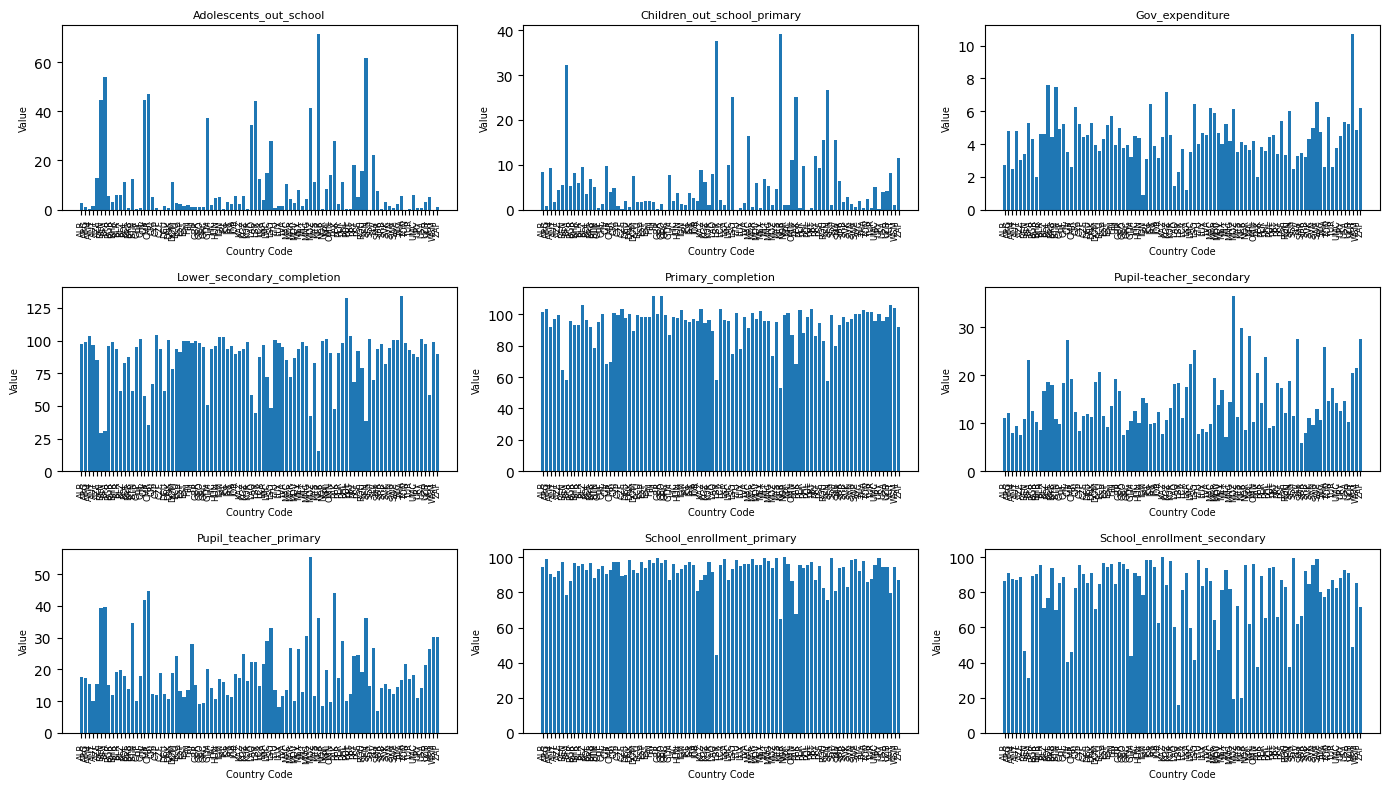

In [24]:
import matplotlib.pyplot as plt

# Select the indicator columns (exclude metadata)
indicator_cols = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

# Convert columns to numeric just in case they're strings
for col in indicator_cols:
    merged_clean[col] = pd.to_numeric(merged_clean[col], errors="coerce")

# Plot histograms: one per indicator, with Country Code on x-axis (bar style)
plt.figure(figsize=(14, 8))
for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)  # create grid of subplots (3 rows x 3 cols)
    plt.bar(merged_clean["Country Code"], merged_clean[col])
    plt.xticks(rotation=90, fontsize=6)
    plt.title(col, fontsize=8)
    plt.ylabel("Value", fontsize=7)
    plt.xlabel("Country Code", fontsize=7)

plt.tight_layout()
plt.show()


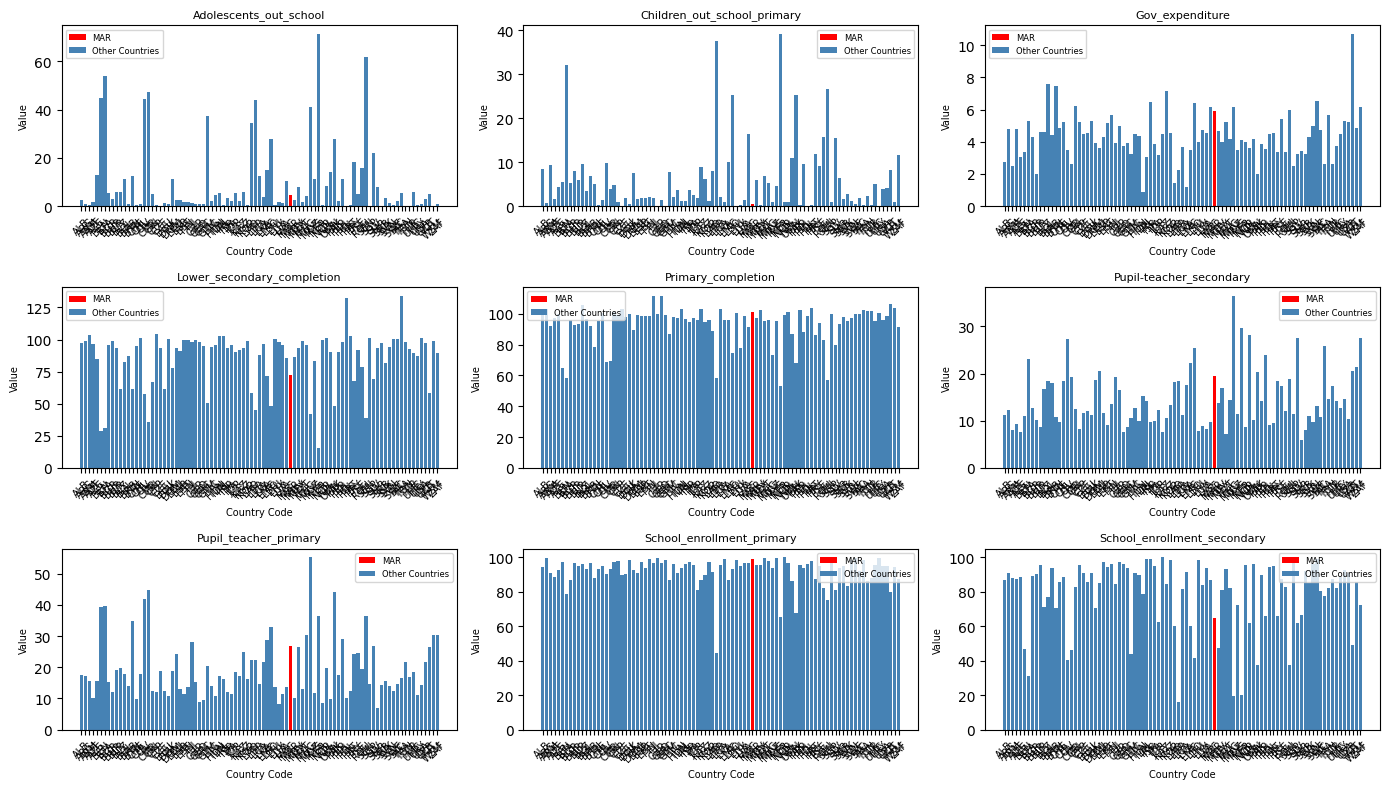

In [25]:
import matplotlib.pyplot as plt

indicator_cols = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

plt.figure(figsize=(14, 8))

for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)

    colors = ["red" if cc == "MAR" else "steelblue" for cc in merged_clean["Country Code"]]

    plt.bar(merged_clean["Country Code"], merged_clean[col], color=colors)
    plt.xticks(rotation=45, fontsize=7)
    plt.title(col, fontsize=8)
    plt.ylabel("Value", fontsize=7)
    plt.xlabel("Country Code", fontsize=7)

    # Add legend only once per subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="red", label="MAR"),
                       Patch(facecolor="steelblue", label="Other Countries")]
    plt.legend(handles=legend_elements, fontsize=6)

plt.tight_layout()
plt.show()


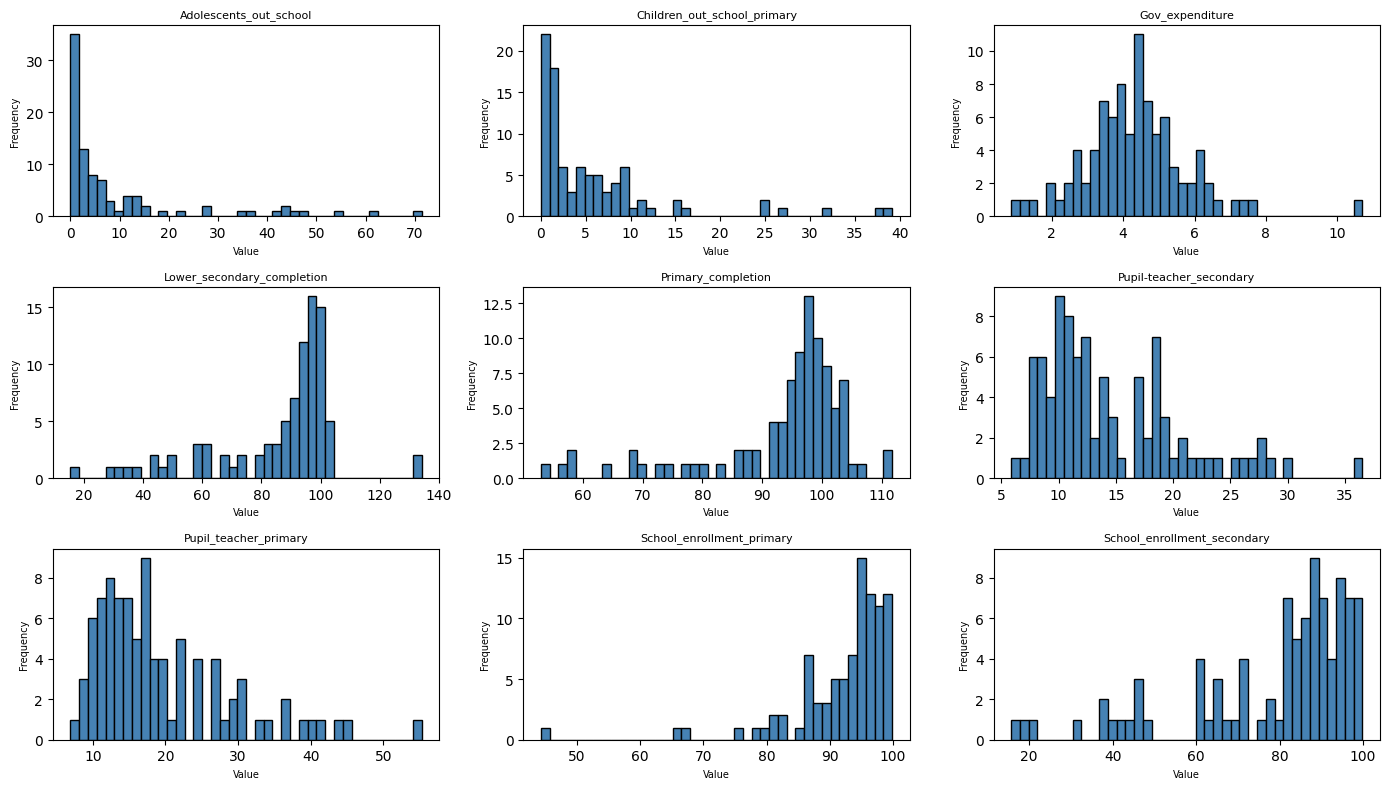

In [26]:
import matplotlib.pyplot as plt

indicator_cols = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

plt.figure(figsize=(14, 8))

for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)
    
    # Plot histogram for the column
    plt.hist(merged_clean[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(col, fontsize=8)
    plt.xlabel("Value", fontsize=7)
    plt.ylabel("Frequency", fontsize=7)

plt.tight_layout()
plt.show()


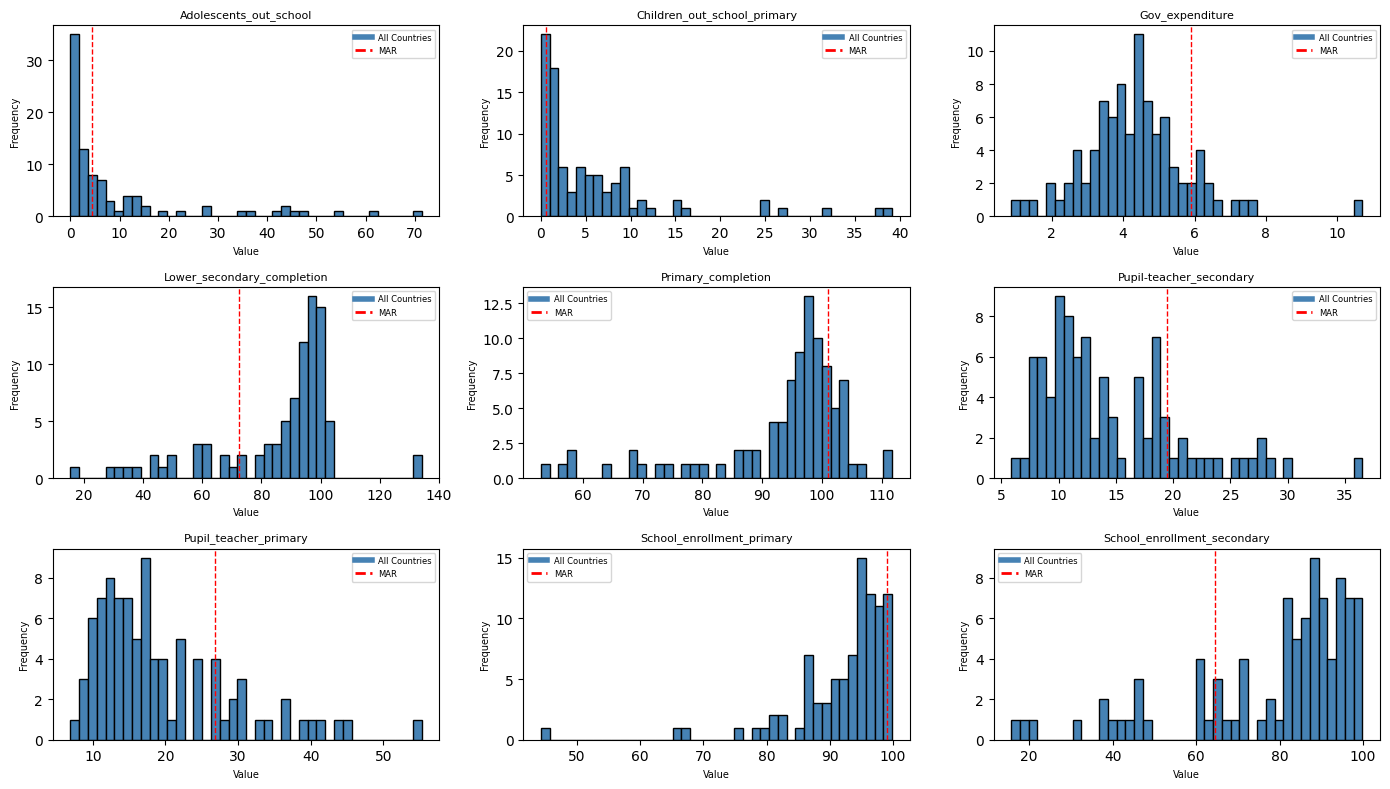

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

indicator_cols = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

plt.figure(figsize=(14, 8))

for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)
    
    # Plot histogram of all countries
    plt.hist(merged_clean[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    
    # If MAR exists, plot a vertical red line for its value
    if "MAR" in merged_clean["Country Code"].values:
        mar_value = merged_clean.loc[merged_clean["Country Code"] == "MAR", col].values[0]
        if pd.notna(mar_value):
            plt.axvline(mar_value, color="red", linestyle="--", linewidth=1)
    
    plt.title(col, fontsize=8)
    plt.xlabel("Value", fontsize=7)
    plt.ylabel("Frequency", fontsize=7)

    # Add legend for MAR
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=4, label="All Countries"),
        Line2D([0], [0], color="red", lw=2, linestyle="--", label="MAR")
    ]
    plt.legend(handles=legend_elements, fontsize=6)

plt.tight_layout()
plt.show()


In [38]:


# --- your function (unchanged) ---
def compute_education_ranking(
    df: pd.DataFrame,
    population_weighted: bool = True,
    perf_weight: float = 0.7,
    contrib_weight: float = 0.3,
) -> pd.DataFrame:
    positive = [
        "primary_completion", "primary_enrollment",
        "lowersec_completion", "secondary_enrollment",
        "spend_gdp"
    ]
    negative = [
        "ptr_primary", "oos_primary",
        "ptr_lowersec", "oos_secondary"
    ]
    perf_vars = [
        "primary_completion", "primary_enrollment",
        "ptr_primary", "oos_primary",
        "lowersec_completion", "secondary_enrollment",
        "ptr_lowersec", "oos_secondary"
    ]
    contrib_var = "spend_gdp"

    def minmax(s):
        return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else 0

    norm = {}
    for c in positive + negative:
        base = minmax(df[c])
        norm[c] = base if c in positive else 1 - base

    norm_df = pd.DataFrame(norm)

    df["performance_score"] = norm_df[perf_vars].mean(axis=1)
    df["contribution_score"] = norm_df[contrib_var]
    df["score_base"] = perf_weight * df["performance_score"] + contrib_weight * df["contribution_score"]

    if population_weighted:
        scale = (df["population"] / df["population"].mean()).clip(0.5, 2.0)
        df["score"] = df["score_base"] * scale
    else:
        df["score"] = df["score_base"]

    df["rank"] = df["score"].rank(ascending=False, method="min").astype(int)

    return df[["country", "performance_score", "contribution_score", "score", "rank"]].sort_values("rank")


# --- map merged_clean columns -> function's expected columns ---
# merged_clean has columns:
# Country Name, Country Code, Adolescents_out_school, Children_out_school_primary, Gov_expenditure,
# Lower_secondary_completion, Primary_completion, Pupil-teacher_secondary, Pupil_teacher_primary,
# School_enrollment_primary, School_enrollment_secondary

colmap = {
    "Country Name": "country",
    "Gov_expenditure": "spend_gdp",
    "Primary_completion": "primary_completion",
    "School_enrollment_primary": "primary_enrollment",
    "Pupil_teacher_primary": "ptr_primary",
    "Children_out_school_primary": "oos_primary",
    "Lower_secondary_completion": "lowersec_completion",
    "School_enrollment_secondary": "secondary_enrollment",
    "Pupil-teacher_secondary": "ptr_lowersec",
    "Adolescents_out_school": "oos_secondary",
}

df_rank = merged_clean.rename(columns=colmap).copy()

# ensure numeric for all indicators (in case they are strings)
indicator_cols = [
    "primary_completion", "primary_enrollment",
    "ptr_primary", "oos_primary",
    "lowersec_completion", "secondary_enrollment",
    "ptr_lowersec", "oos_secondary",
    "spend_gdp",
]
for c in indicator_cols:
    df_rank[c] = pd.to_numeric(df_rank[c], errors="coerce")

# If you DON'T have a 'population' column in merged_clean, set population_weighted=False
use_pop_weight = "population" in df_rank.columns

ranking = compute_education_ranking(
    df_rank[["country"] + (["population"] if use_pop_weight else []) + indicator_cols],
    population_weighted=use_pop_weight,   # False if no population
    perf_weight=0.7,
    contrib_weight=0.3,
)

print(ranking.head(20))

             country  performance_score  contribution_score     score  rank
215           Sweden           0.890395            0.577480  0.796521     1
109           Israel           0.866785            0.568358  0.777257     2
51            Cyprus           0.903584            0.444901  0.765979     3
182           Poland           0.930150            0.365062  0.760623     4
56           Denmark           0.887411            0.450484  0.756333     5
73           Finland           0.868874            0.490576  0.755385     6
250          Vanuatu           0.641467            1.000000  0.749027     7
69           Estonia           0.880328            0.439455  0.748066     8
186         Portugal           0.906100            0.375967  0.747060     9
152            Malta           0.871534            0.441546  0.742537    10
214         Slovenia           0.877902            0.417128  0.739670    11
79           Georgia           0.929035            0.293822  0.738471    12
116  Kyrgyz 

In [39]:
# Save the DataFrame `ranking` to an Excel file named ranking01.xlsx
ranking.to_excel("ranking01.xlsx", index=False, sheet_name="Ranking")

In [30]:
ranking.head(39)

,country,performance_score,contribution_score,score,rank
215,Sweden,0.890395,0.577480,0.796521,1
109,Israel,0.866785,0.568358,0.777257,2
51,Cyprus,0.903584,0.444901,0.765979,3
182,Poland,0.930150,0.365062,0.760623,4
56,Denmark,0.887411,0.450484,0.756333,5
73,Finland,0.868874,0.490576,0.755385,6
250,Vanuatu,0.641467,1.000000,0.749027,7
69,Estonia,0.880328,0.439455,0.748066,8
186,Portugal,0.906100,0.375967,0.747060,9
152,Malta,0.871534,0.441546,0.742537,10


In [40]:
def topsis_rank(df, indicators, benefit_cols, cost_cols, weights=None):
    """
    df: DataFrame with an 'item' column (name/id) + indicator columns
    indicators: list of all indicator column names (numeric)
    benefit_cols: subset of indicators where higher is better
    cost_cols: subset where lower is better
    weights: optional list/array of same length as indicators (defaults equal)

    returns: df with TOPSIS score and rank (higher score = better)
    """
    X = df[indicators].astype(float).values
    n, m = X.shape

    # 1) Normalize columns (L2 norm)
    denom = np.linalg.norm(X, axis=0)
    denom[denom == 0] = 1.0
    Xn = X / denom

    # 2) Weights
    if weights is None:
        w = np.ones(m) / m
    else:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
    Xw = Xn * w

    # 3) Ideal best / worst
    # For benefits: best = max, worst = min; for costs: best = min, worst = max
    best = np.zeros(m)
    worst = np.zeros(m)
    for j, col in enumerate(indicators):
        col_vals = Xw[:, j]
        if col in benefit_cols:
            best[j] = col_vals.max()
            worst[j] = col_vals.min()
        elif col in cost_cols:
            best[j] = col_vals.min()
            worst[j] = col_vals.max()
        else:
            raise ValueError(f"Indicator {col} must be in benefit_cols or cost_cols")

    # 4) Distances
    d_best = np.linalg.norm(Xw - best, axis=1)
    d_worst = np.linalg.norm(Xw - worst, axis=1)

    # 5) Closeness score & rank
    score = d_worst / (d_best + d_worst + 1e-12)
    out = df.copy()
    out["topsis_score"] = score
    out["topsis_rank"] = out["topsis_score"].rank(ascending=False, method="min").astype(int)
    return out.sort_values("topsis_rank")


In [44]:
indicators = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

benefit_cols = [
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]

cost_cols = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
]

ranking = topsis_rank(
    merged_clean[["Country Name", "Country Code"] + indicators].dropna(),
    indicators=indicators,
    benefit_cols=benefit_cols,
    cost_cols=cost_cols,
    weights=None  # or pass a list of len(indicators)
)
print(ranking[["Country Name","Country Code","topsis_score","topsis_rank"]].head(39))


        Country Name Country Code  topsis_score  topsis_rank
215           Sweden          SWE      0.851867            1
109           Israel          ISR      0.840324            2
51            Cyprus          CYP      0.834840            3
56           Denmark          DNK      0.830608            4
69           Estonia          EST      0.827594            5
73           Finland          FIN      0.825277            6
182           Poland          POL      0.825107            7
37       Switzerland          CHE      0.822186            8
214         Slovenia          SVN      0.818758            9
186         Portugal          PRT      0.818736           10
14           Austria          AUT      0.816655           11
138       Luxembourg          LUX      0.816597           12
139           Latvia          LVA      0.813603           13
9          Argentina          ARG      0.808180           14
169           Norway          NOR      0.807713           15
218       Seychelles    

In [45]:
ranking.shape

(91, 13)

In [42]:
# Save the DataFrame `ranking` to an Excel file named ranking01.xlsx
ranking.to_excel("ranking02.xlsx", index=False, sheet_name="Ranking")

In [35]:
import numpy as np
import pandas as pd

def topsis_rank(df, indicators, benefit_cols, cost_cols, weights=None):
    X = df[indicators].astype(float).values
    n, m = X.shape

    # Normalize
    denom = np.linalg.norm(X, axis=0)
    denom[denom == 0] = 1
    Xn = X / denom

    # Weights
    if weights is None:
        w = np.ones(m) / m
    else:
        w = np.array(weights) / np.sum(weights)
    Xw = Xn * w

    # Ideal best/worst
    best, worst = np.zeros(m), np.zeros(m)
    for j, col in enumerate(indicators):
        if col in benefit_cols:
            best[j], worst[j] = Xw[:, j].max(), Xw[:, j].min()
        elif col in cost_cols:
            best[j], worst[j] = Xw[:, j].min(), Xw[:, j].max()

    # Distances & scores
    d_best = np.linalg.norm(Xw - best, axis=1)
    d_worst = np.linalg.norm(Xw - worst, axis=1)
    score = d_worst / (d_best + d_worst + 1e-12)

    out = df[["Country Name", "Country Code"]].copy()
    out["topsis_score"] = score
    out["topsis_rank"] = out["topsis_score"].rank(ascending=False, method="min").astype(int)
    return out.sort_values("topsis_rank")

# Define your indicators and directions
indicators = [
    "Adolescents_out_school",
    "Children_out_school_primary",
    "Gov_expenditure",
    "Lower_secondary_completion",
    "Primary_completion",
    "Pupil-teacher_secondary",
    "Pupil_teacher_primary",
    "School_enrollment_primary",
    "School_enrollment_secondary",
]
benefit_cols = ["Gov_expenditure","Lower_secondary_completion","Primary_completion",
                "School_enrollment_primary","School_enrollment_secondary"]
cost_cols = ["Adolescents_out_school","Children_out_school_primary",
             "Pupil-teacher_secondary","Pupil_teacher_primary"]

ranking = topsis_rank(merged_clean.dropna(subset=indicators), indicators, benefit_cols, cost_cols)
print(ranking.head(39))

        Country Name Country Code  topsis_score  topsis_rank
215           Sweden          SWE      0.851867            1
109           Israel          ISR      0.840324            2
51            Cyprus          CYP      0.834840            3
56           Denmark          DNK      0.830608            4
69           Estonia          EST      0.827594            5
73           Finland          FIN      0.825277            6
182           Poland          POL      0.825107            7
37       Switzerland          CHE      0.822186            8
214         Slovenia          SVN      0.818758            9
186         Portugal          PRT      0.818736           10
14           Austria          AUT      0.816655           11
138       Luxembourg          LUX      0.816597           12
139           Latvia          LVA      0.813603           13
9          Argentina          ARG      0.808180           14
169           Norway          NOR      0.807713           15
218       Seychelles    

In [37]:
import numpy as np
import pandas as pd
from xgboost import XGBRanker

# 1) Features & meta
indicators = [
    "Adolescents_out_school","Children_out_school_primary","Gov_expenditure",
    "Lower_secondary_completion","Primary_completion","Pupil-teacher_secondary",
    "Pupil_teacher_primary","School_enrollment_primary","School_enrollment_secondary",
]
benefit = ["Gov_expenditure","Lower_secondary_completion","Primary_completion",
           "School_enrollment_primary","School_enrollment_secondary"]
cost    = ["Adolescents_out_school","Children_out_school_primary",
           "Pupil-teacher_secondary","Pupil_teacher_primary"]

X = merged_clean[indicators].apply(pd.to_numeric, errors="coerce").dropna()
meta = merged_clean.loc[X.index, ["Country Name","Country Code"]].reset_index(drop=True)

# 2) Weak continuous score (benefit - cost) -> then bin to integers 0..4
y_cont = X[benefit].mean(axis=1) - X[cost].mean(axis=1)
# 5 bins: 0 (worst) … 4 (best)
y_int = pd.qcut(y_cont, q=5, labels=False, duplicates="drop").astype(int)

# 3) Single global group
group = [len(X)]

# 4) Monotone constraints (+1 benefits, -1 costs) aligned to indicators order
mono_vec = [(+1 if c in benefit else -1) for c in indicators]
mono = "(" + ",".join(map(str, mono_vec)) + ")"

# 5) Train listwise ranker
ranker = XGBRanker(
    objective="rank:ndcg",      # listwise
    eval_metric="ndcg",
    learning_rate=0.06,
    max_depth=5,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    monotone_constraints=mono,
    tree_method="hist",
)

ranker.fit(X.values, y_int.values, group=group)

# 6) Predict & rank
scores = ranker.predict(X.values)
rank_df = meta.copy()
rank_df["score_xgb"] = scores
rank_df["rank_xgb"] = rank_df["score_xgb"].rank(ascending=False, method="min").astype(int)
rank_df = rank_df.sort_values("rank_xgb")
print(rank_df.head(39))


      Country Name Country Code  score_xgb  rank_xgb
61          Norway          NOR   1.961194         1
73       Singapore          SGP   1.961194         1
79          Sweden          SWE   1.945572         3
29  United Kingdom          GBR   1.945572         3
49       Lithuania          LTU   1.891761         5
68        Portugal          PRT   1.815566         6
19          Cyprus          CYP   1.763369         7
22         Denmark          DNK   1.623210         8
1        Argentina          ARG   1.607588         9
31          Greece          GRC   1.240463        10
27         Finland          FIN   1.238861        11
67          Poland          POL   1.105832        12
78        Slovenia          SVN   0.998876        13
36         Ireland          IRL   0.885370        14
26         Estonia          EST   0.884217        15
56           Malta          MLT   0.846780        16
30         Georgia          GEO   0.828932        17
42     Korea, Rep.          KOR   0.707645    